In [1]:
#Install Pre-Req
!pip install easyocr;

In [2]:
#Import Libs
from matplotlib import pyplot as plot
from PIL import Image

import matplotlib as mpl
import urllib.request
import urllib.parse
import numpy as np
import easyocr
import math
import cv2
import re

In [3]:
# Suppress the Warnings
import warnings
import logging

warnings.filterwarnings("ignore", message="Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.", category=UserWarning)
warnings.filterwarnings("ignore", message="'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.", category=UserWarning)
logging.getLogger('easyocr').setLevel(logging.ERROR)

In [4]:
#Define the EasyOCR Reader
reader = easyocr.Reader(['en']);

In [5]:
#Define the Image URL
image_url = 'https://raw.githubusercontent.com/jrafa1607/Digital_Gauge_Solution_CV/main/Dataset/img01.BMP'

In [6]:
#Open the Image
with urllib.request.urlopen(image_url) as url:
    s = url.read()

In [7]:
#Convert to a Numpy Array and Decode with cv2
original = cv2.imdecode(np.frombuffer(s, np.uint8), -1)

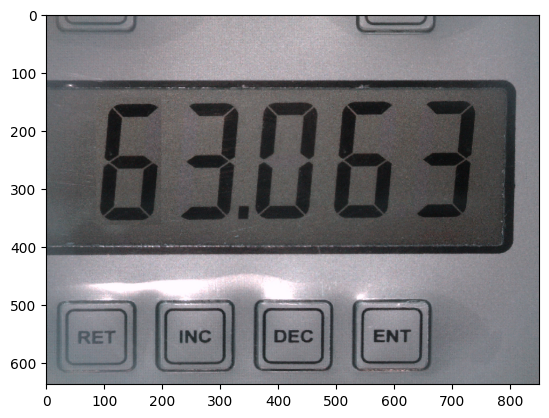

In [8]:
#Show the Image
plot.imshow(original,cmap='gray')
plot.show()

In [9]:
#Define the Interest Region
x, y, w, h = 65, 135, 685, 230
img = original[y:y+h, x:x+w]

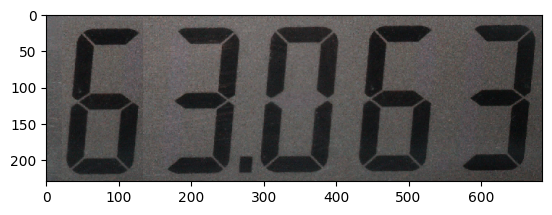

In [10]:
#Show the Results
plot.imshow(img,cmap='gray')
plot.show()

In [11]:
# Apply Non-Local Means Denoising
img = cv2.fastNlMeansDenoising(img, None, 20, 7, 21)

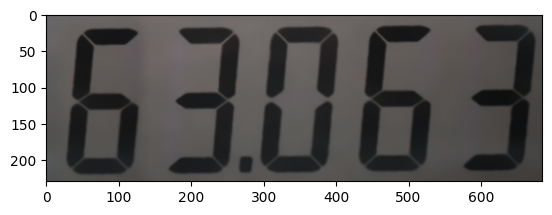

In [12]:
#Show the Results
plot.imshow(img,cmap='gray')
plot.show()

In [13]:
#Apply the Normalization with MinMax
norm_img = np.zeros((img.shape[0], img.shape[1]))
img = cv2.normalize(img, norm_img, 0, 255, cv2.NORM_MINMAX)

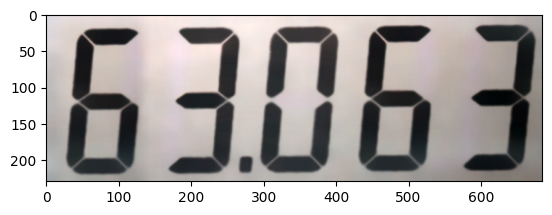

In [14]:
#Show the Results
plot.imshow(img,cmap='gray')
plot.show()

In [15]:
#Apply Filter for Dark Colors in the Image
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1,2))
img = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel,iterations=1)

In [16]:
#Apply Erosion
EE = cv2.getStructuringElement(cv2.MORPH_RECT,(5,5))
img = cv2.erode(img,EE,iterations = 2)

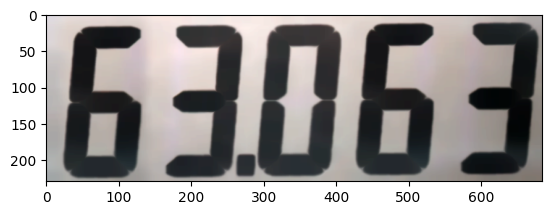

In [17]:
#Show the Results
plot.imshow(img,cmap='gray')
plot.show()

In [18]:
#Convert to Grayscale
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [19]:
#Apply Canny to Create Edges
canny_edges = cv2.Canny(img, 150, 200)
black_edges_mask = cv2.bitwise_not(canny_edges)
img = cv2.bitwise_and(img, black_edges_mask)

In [20]:
#Fill the Canny Edges
kernel_fill = np.ones((8,8), np.uint8)
img = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel_fill)

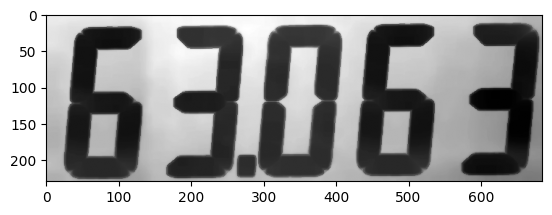

In [21]:
#Show the Results
plot.imshow(img,cmap='gray')
plot.show()

In [22]:
#Find the Average Grayscale Level for File-tuning
print(f"Average Grayscale Level: {np.mean(img):.2f}")

Average Grayscale Level: 122.99


In [23]:
#Define Threshold
if np.mean(img) > 60 and np.mean(img) < 90:
    threshold_value = 70
elif np.mean(img) > 121.7 and np.mean(img) < 130:
    threshold_value = 138
else:
    threshold_value = 90

In [24]:
# Apply Threshold
ret_manual, img = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)

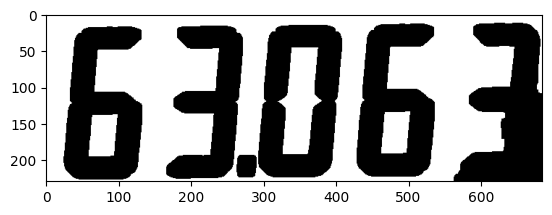

In [25]:
#Show the Results
plot.imshow(img,cmap='gray')
plot.show()

In [26]:
#Read the Image
text = " "
text = text + str(reader.readtext(img, detail = 0, allowlist='0123456789', paragraph = True));

In [27]:
#Fix the Text
text = re.findall(r'\d+', text)
text = ''.join(text)

In [28]:
#Show the Numbers
print(text)

63063


All the Numbers: 6 3 0 6 3


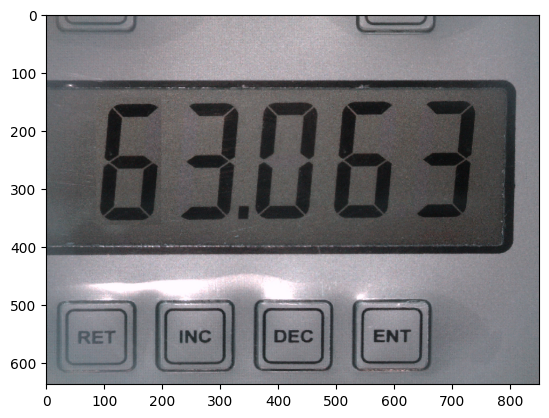

In [29]:
#Show the Final Results
print("All the Numbers: " + text[0], text[1], text[2], text[3], text[4])
plot.imshow(original,cmap='gray')
plot.show()